## Monkeypox differential diagnosis using a Modified Xception Model

Monkeypox images are compared to 'Chickenpox' and 'Measles' skin leasions because of their resemblance to the monkeypox rash and pustules in initial state.
Most of the images provided were augmented images therefore they were used for training but for validation true images were chosen

In [1]:
# Necessary imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing import image_dataset_from_directory
import tensorflow as tf
import os
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Conv2D, Add
from tensorflow.keras.layers import SeparableConv2D, ReLU
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import MaxPool2D
from tensorflow.keras.layers import GlobalAvgPool2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras import Model
import warnings
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

print("TF version:", tf.__version__)

TF version: 2.17.1


In [2]:
import os
print(os.listdir("../input/"))


['monkeypox-skin-lesion-dataset', 'mpox-skin-lesion-dataset-version-20-msld-v20']


### Loading and Processing the data

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory("/kaggle/input/monkeypox-skin-lesion-dataset/Fold1/Fold1/Fold1/Train",    
    labels='inferred',
    label_mode='int',
    class_names=None,
    color_mode='rgb',
    batch_size=32,
    image_size=(299, 299),
    shuffle=True,
    seed=42,                                                   
    validation_split=0.2,
    subset="training",                                                  
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=False,
 )

Found 2142 files belonging to 2 classes.
Using 1714 files for training.


In [6]:
val_ds = tf.keras.utils.image_dataset_from_directory("/kaggle/input/monkeypox-skin-lesion-dataset/Fold1/Fold1/Fold1/Val",
  validation_split=None,
  seed=123,
  image_size=(299, 299),
  batch_size=32)

Found 420 files belonging to 2 classes.


In [7]:
class_names = train_ds.class_names
print(class_names)

['Monkeypox', 'Others']


### Previewing images

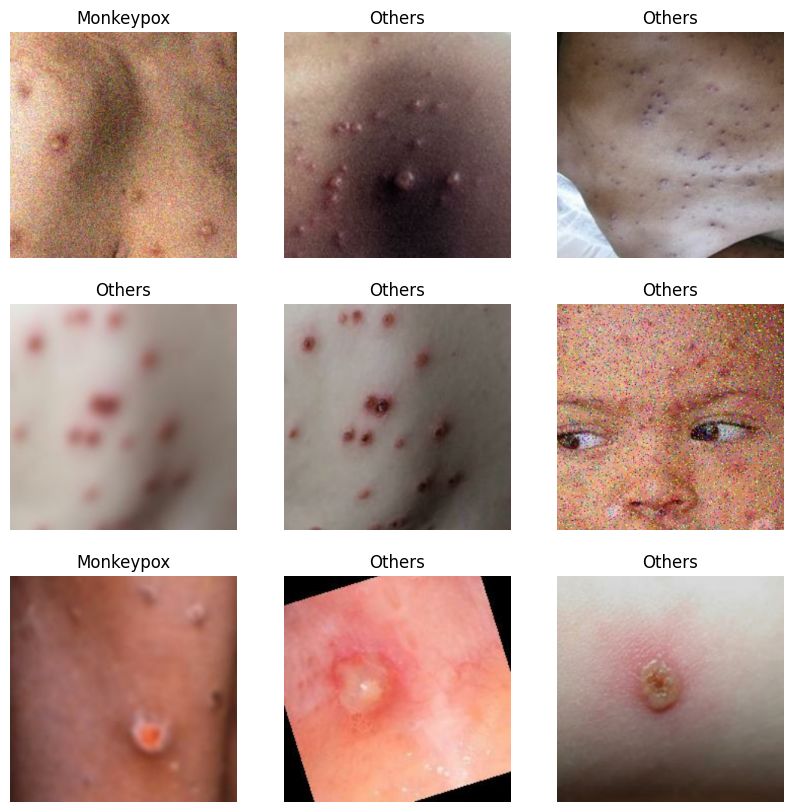

In [8]:
# Preview a batch of images from the dataset
plt.figure(figsize=(10, 10))  # Create a figure with a 10x10 size [[3]]
for images, labels in train_ds.take(1):  # Take one batch of data
    for i in range(9):  # Display the first 9 images
        ax = plt.subplot(3, 3, i + 1)  # Create a 3x3 grid of subplots [[5]]
        plt.imshow(images[i].numpy().astype("uint8"))  # Convert tensor to numpy and display the image [[3]]
        plt.title(class_names[labels[i]])  # Add the class name as the title [[8]]
        plt.axis("off")  # Turn off axis labels for cleaner visualization [[6]]
plt.show()

In [9]:
for image_batch, labels_batch in train_ds:
    print(image_batch.shape)
    print(labels_batch.shape)
    break

(32, 299, 299, 3)
(32,)


In [29]:
# data_augmentation = tf.keras.Sequential([
#     tf.keras.layers.RandomFlip("horizontal"),
#     tf.keras.layers.RandomRotation(0.1),
#     tf.keras.layers.RandomZoom(0.1),
# ])

# train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

### Data Normalization

In [10]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
print(np.min(first_image), np.max(first_image))

0.0 0.99971855


### Configuring the data for better performance

In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

### Creating the modified Xception model

In [12]:
from tensorflow.keras.layers import MaxPool2D

In [13]:
# Creating the Conv-Batch Norm block

def conv_bn(x, filters, kernel_size, strides=1):
    x = Conv2D(filters=filters, kernel_size=kernel_size, strides=strides,
              padding="same", use_bias=False)(x)
    x = BatchNormalization()(x)
    return x   

In [14]:
# Creating separable Conv-batch norm block

def sep_bn(x, filters, kernel_size, strides=1):
    x = SeparableConv2D(filters=filters, kernel_size=kernel_size, strides=strides,
              padding="same", use_bias=False)(x)
    x = BatchNormalization()(x)  
    return x  

In [15]:
# functions for Entry,Middle and Exit flow

def entry_flow(x):    
    x = conv_bn(x, filters = 32, kernel_size =3, strides=2)
    x = ReLU()(x)
    x = conv_bn(x, filters = 64, kernel_size =3, strides=1)
    tensor =ReLU()(x)
    x = sep_bn(tensor, filters=128, kernel_size = 3)
    x = ReLU()(x)
    x = sep_bn(tensor, filters=128, kernel_size = 3)
    x = MaxPool2D(pool_size = 3, strides=2, padding="same")(x)      #poolsize
    tensor = conv_bn(tensor, filters=128, kernel_size=1, strides=2)
    x = Add()([tensor, x])
    x = ReLU()(x)
    x = sep_bn(x, filters=256, kernel_size = 3)
    x =ReLU()(x)
    x = sep_bn(x, filters=256, kernel_size = 3)
    x = MaxPool2D(pool_size = 3, strides = 2, padding = "same")(x)    
    tensor=conv_bn(tensor,filters=256, kernel_size=1, strides=2)
    x = Add()([tensor, x])
    x = ReLU()(x)
    x = sep_bn(x, filters=728, kernel_size = 3)
    x =ReLU()(x)
    x = sep_bn(x, filters=728, kernel_size = 3)
    x = MaxPool2D(pool_size = 3, strides = 2, padding = "same")(x)
    tensor = conv_bn(tensor,filters=728, kernel_size=1, strides=2)
    x = Add()([tensor, x])
    return x

In [16]:
# middle flow

def middle_flow(tensor):
    for _ in range(8):
        x = ReLU()(tensor)
        x = sep_bn(x, filters=728, kernel_size = 3)
        x = ReLU()(x)
        x = sep_bn(x, filters=728, kernel_size = 3)
        x = ReLU()(x)
        x = sep_bn(x, filters=728, kernel_size = 3)
        x = ReLU()(x)
        tensor =Add()([tensor, x])
    return tensor    

In [17]:
# exit flow
def exit_flow(tensor):
    x = ReLU()(tensor)
    x = sep_bn(x, filters=728, kernel_size = 3)
    x = ReLU()(x)
    x = sep_bn(x, filters=1024, kernel_size = 3)
    x = MaxPool2D(pool_size = 3, strides=2, padding="same")(x)
    tensor = conv_bn(tensor, filters=1024, kernel_size=1, strides=2)
    x = Add()([tensor, x])
    x = sep_bn(x, filters=1536, kernel_size = 3)
    x = ReLU()(x)
    x = sep_bn(x, filters=2048, kernel_size = 3)
    x = ReLU()(x)  
    x = sep_bn(x, filters = 4096,  kernel_size=3)
    x = ReLU()(x) 
    x = GlobalAvgPool2D()(x)
    x = Dense (units = 2, activation ="softmax")(x)
        
    return x   

In [18]:
input = Input(shape = (299, 299, 3))
x = entry_flow(input)
x = middle_flow(x)
output = exit_flow(x)

In [19]:
model =Model(inputs=input, outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 299, 299, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 150, 150, 32)   │            864 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 150, 150, 32)   │            128 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu (ReLU)              │ (None, 150, 150, 32)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 150, 150, 64)   │         18,432 │ re_lu[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 150, 150, 64)   │            256 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_1 (ReLU)            │ (None, 150, 150, 64)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_1        │ (None, 150, 150, 128)  │          8,768 │ re_lu_1[0][0]          │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 75, 75, 128)    │          8,192 │ re_lu_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 150, 150, 128)  │            512 │ separable_conv2d_1[0]… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 75, 75, 128)    │            512 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 75, 75, 128)    │              0 │ batch_normalization_3… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 75, 75, 128)    │              0 │ batch_normalization_4… │
│                           │                        │                │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_3 (ReLU)            │ (None, 75, 75, 128)    │              0 │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_2        │ (None, 75, 75, 256)    │         33,920 │ re_lu_3[0][0]          │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_5

 Total params: 29,275,050 (111.68 MB)

 Trainable params: 29,212,586 (111.44 MB)

 Non-trainable params: 62,464 (244.00 KB)

In [21]:
from tensorflow.keras.optimizers import Adam

# Define the learning rate
learning_rate = 0.001

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [22]:
epochs=50
history = model.fit(
  train_ds,
  validation_data=val_ds,
    epochs=epochs,
   )          
  

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.5677 - loss: 0.9778 - val_accuracy: 0.4000 - val_loss: 0.6932
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 440ms/step - accuracy: 0.6555 - loss: 0.6258 - val_accuracy: 0.4000 - val_loss: 0.6935
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 440ms/step - accuracy: 0.6846 - loss: 0.6036 - val_accuracy: 0.4000 - val_loss: 0.6934
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 440ms/step - accuracy: 0.7294 - loss: 0.5579 - val_accuracy: 0.4000 - val_loss: 0.6935
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 440ms/step - accuracy: 0.7428 - loss: 0.5323 - val_accuracy: 0.4190 - val_loss: 0.6924
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 440ms/step - accuracy: 0.7898 - loss: 0.4397 - val_accuracy: 0.6000 - val_loss: 0.6737
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 440ms/step - accuracy: 0.8435 - loss: 0.3586 - val_accuracy: 0.4476 - val_loss: 0.7090
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 439ms/step - accuracy: 0.8461 - loss: 0.3350 - val_accura

In [27]:
from sklearn.metrics import classification_report, f1_score

# Predict on validation dataset
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    
assert set(y_true) == set(range(len(class_names))), "y_true doesn't match class_names"
assert set(y_pred) <= set(range(len(class_names))), "y_pred out of class index range"

# Print report
print(classification_report(y_true, y_pred, target_names=class_names))

# Get macro F1
macro_f1 = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score: {macro_f1:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
              precision    recall  f1-score   support

   Monkeypox       0.49      0.48      0.48       168
      Others       0.66      0.66      0.66       252

    accuracy                           0.59       420
   macro avg       0.57      0.57      0.57       420
weighted avg       0.59      0.59      0.59       420

Macro F1 Score: 0.5705


In [30]:
# Evaluate the model on the validation dataset
test_loss, test_accuracy = model.evaluate(val_ds)

print(f"\n✅ Testing Accuracy: {test_accuracy * 100:.2f}%")
print(f"🧪 Testing Loss: {test_loss:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.5924 - loss: 2.9694

✅ Testing Accuracy: 58.81%
🧪 Testing Loss: 2.8869
